# --- Notebook : Classification binaire (fonction d'activation tanh) - Test sur le dataset 

# Les imports

In [21]:

import numpy as np
import pandas as pd
import ctypes
import matplotlib.pyplot as plt

from IPython.display import display
from PIL import Image
import os

In [22]:
# Charger la bibliothèque Rust compilée (DLL / SO)
lib = ctypes.CDLL("target/release/mymodel.dll") 

In [23]:
# Définir les types des fonctions externes
lib.create_linear_model.argtypes = [ctypes.c_size_t, ctypes.c_double, ctypes.c_size_t]
lib.create_linear_model.restype = ctypes.c_void_p

lib.train_linear_model_classification.argtypes = [
    ctypes.c_void_p,
    ctypes.POINTER(ctypes.c_double),
    ctypes.POINTER(ctypes.c_double),
    ctypes.c_size_t,
    ctypes.c_size_t,
]

lib.predict_linear_model_classification.argtypes = [ctypes.c_void_p, ctypes.POINTER(ctypes.c_double), ctypes.c_size_t]
lib.predict_linear_model_classification.restype = ctypes.c_double


In [24]:

# Charger dataset d'entraînement
df_train = pd.read_csv("dataset_train.csv")

# Séparer les features (X) et les labels (y)
X_train = df_train.drop(columns=["label"]).to_numpy(dtype=np.float64)
y_train = df_train["label"].to_numpy(dtype=np.float64)

# Convertir en binaire : "lettre A" (label 0) vs "autres" //afin de tester sur une image A
#Le modèle binaire doit répondre avec deux valeurs possibles :
# 1.0 si c’est un A (label original == 0)
# -1.0 si ce n’est pas un A (label original ≠ 0)

y_train_binary = np.where(y_train == 0, 1.0, -1.0) # un filtrage logique pour transformer les classes multiples → en binaire.

# Afficher les formes
print("Shape de X :", X_train.shape)
print("Shape de y :", y_train.shape)
print("Unique labels :", np.unique(y_train))
print(" labels :", y_train_binary)
print("A", np.count_nonzero(y_train_binary == 1))

Shape de X : (117, 12288)
Shape de y : (117,)
Unique labels : [ 0.  1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11. 12. 13. 14. 15. 16. 17.
 18. 19. 20. 21. 22. 23. 24. 25. 26. 27. 28. 29. 30. 31. 32. 33. 34. 35.]
 labels : [-1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1.
 -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1.
 -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1.
 -1. -1. -1. -1. -1. -1.  1.  1.  1.  1.  1.  1. -1. -1. -1. -1. -1. -1.
 -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1.
 -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1.
 -1. -1. -1. -1. -1. -1. -1. -1. -1.]
A 6


In [25]:

# Créer le modèle
n_features = X_train.shape[1] #X_train.shape[1] reprèsente le nombre de colonnes 12288 features 
model = lib.create_linear_model(n_features, 0.001, 5000)

# Entraîner
lib.train_linear_model_classification(
    model,
    X_train.ctypes.data_as(ctypes.POINTER(ctypes.c_double)),
    y_train_binary.ctypes.data_as(ctypes.POINTER(ctypes.c_double)),
    X_train.shape[0],
    X_train.shape[1]
)
print("Modèle entraîné.")


Modèle entraîné.


In [26]:
# Charger le dataset de test
df_test = pd.read_csv("dataset_test.csv")
X_test = df_test.drop(columns=["label"]).to_numpy(dtype=np.float64)
y_test = df_test["label"].to_numpy(dtype=np.float64)

# Même principe : binaire → 1 si 'A', sinon -1
y_test_binary = np.where(y_test == 0, 1.0, -1.0)

# Afficher les formes
print("Shape de X :", X_test.shape)
print("Shape de y :", y_test.shape)
print("Unique labels :", np.unique(y_test))
print(" labels :", y_test_binary)
print("A", np.count_nonzero(y_test_binary == 1))


Shape de X : (34, 12288)
Shape de y : (34,)
Unique labels : [ 0.  1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11. 12. 13. 14. 15. 16. 17.
 18. 19. 20. 21. 22. 23. 24. 25.]
 labels : [ 1.  1.  1.  1.  1.  1.  1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1.
 -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1.]
A 7


In [27]:
# Prédictions
preds = []
for x in X_test:
    pred = lib.predict_linear_model_classification(
        model,
        x.ctypes.data_as(ctypes.POINTER(ctypes.c_double)),
        len(x)
    )
    preds.append(1.0 if pred >= 0.0 else -1.0)

# Évaluation
preds = np.array(preds)
accuracy = (preds == y_test_binary).mean()
print(f"Taux de bonne classification sur test (est-ce un A ?) : {accuracy * 100:.2f}%")


Taux de bonne classification sur test (est-ce un A ?) : 79.41%


Nombre d'images détectées : 36
Taille de y_test_binary    : 34
Taille de preds            : 34
0 - dataset/test\A\300.jpeg
Image 300.jpeg — Prédit : Pas A | Réel : A


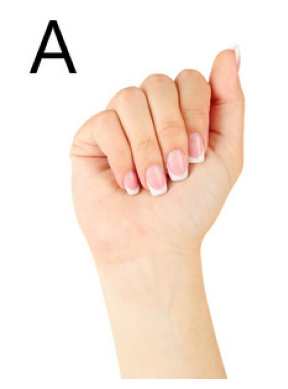

1 - dataset/test\A\A_001.jpg
Image A_001.jpg — Prédit : Pas A | Réel : A


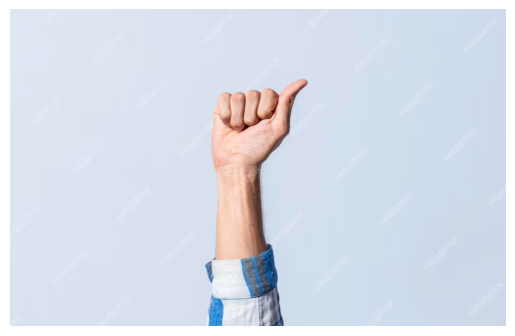

2 - dataset/test\A\A_002.jpg
Image A_002.jpg — Prédit : Pas A | Réel : A


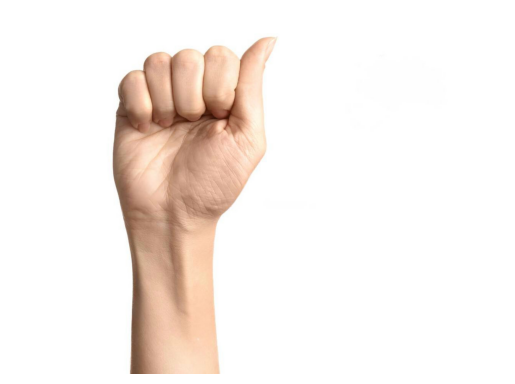

3 - dataset/test\A\A_003.jpg


UnidentifiedImageError: cannot identify image file 'C:\\Users\\akric\\OneDrive\\Documents\\maching_learning\\projet_annuel\\PA\\dataset\\test\\A\\A_003.jpg'

In [31]:

# Chemin des images dans le dossier de test
test_image_paths = []
for root, _, files in os.walk("dataset/test"):
    for file in sorted(files):  # tri pour avoir un ordre constant
        if file.lower().endswith(('.png', '.jpg', '.jpeg')):
            test_image_paths.append(os.path.join(root, file))

print(f"Nombre d'images détectées : {len(test_image_paths)}")
print(f"Taille de y_test_binary    : {len(y_test_binary)}")
print(f"Taille de preds            : {len(preds)}")

# Afficher image + prédiction + vrai label
for i, path in enumerate(test_image_paths):
    print(f"{i} - {path}")
    if i >= len(preds):  # sécurité
        break

    img = Image.open(path)
    pred_label = "A" if preds[i] == 1.0 else "Pas A"
    true_label = "A" if y_test_binary[i] == 1.0 else "Pas A"

    print(f"Image {os.path.basename(path)} — Prédit : {pred_label} | Réel : {true_label}")
    plt.imshow(img)
    plt.axis('off')
    plt.show()

